<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/multi_class_classification_with_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 다중분류 (Multi-class Classification) 쉽게 이해하기

> **비전공자를 위한 친절한 입문 노트북 + 직접 코딩 실습 포함**

---

## 📚 오늘의 학습 목표

1. **이진분류 vs 다중분류**가 뭐가 다른지
2. **소프트맥스(Softmax)** 가 도대체 뭐 하는 친구인지 (점수→확률 변환기!)
3. **원핫 인코딩**과 **크로스 엔트로피 손실**이 왜 필요한지
4. 직접 코드로 **3종 붓꽃을 분류**하는 모델을 만들 수 있게 됩니다

## 🧭 진행 순서

| 단계 | 내용 |
|---|---|
| 1 | 분류 문제란? (우편물 분류 비유) |
| 2 | Softmax → **✏️ 직접 구현** |
| 3 | 원핫 인코딩 → **✏️ 직접 구현** |
| 4 | 크로스 엔트로피 → **✏️ 직접 구현** |
| 5 | 실습 ①: 2D 가상 데이터 분류 + 결정경계 그리기 |
| 6 | 평가 도구: 혼동행렬 |
| 7 | 실습 ②: 실전 — Iris(붓꽃) 3종 분류 |
| 8 | 정리 |

## 🛠️ 실습 코드 사용법

이 노트북에는 **3개의 빈칸 채우기 연습**이 있습니다.

- **✏️ 연습 셀**: 빈칸(`...`)을 채워서 함수를 완성합니다
- **🧪 자가 검증 셀**: 실행하면 정답인지 자동으로 알려줍니다
- **🔑 정답 보기**: 충분히 시도해본 뒤 펼쳐보세요

> 💡 **이전 시간 복습**: 미니배치 GD로 "산을 내려오는" 방법을 배웠죠.
> 오늘은 그 방법을 **분류 문제**에 그대로 써먹습니다.

## 🔧 0. 환경 준비

In [3]:
# 한글 폰트 설치 (코랩 1회만)
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
np.random.seed(42)
print("✅ 환경 준비 완료!")

✅ 환경 준비 완료!


## 📮 1. 분류 문제란? — 우편물 분류 비유

### 🚪 이진분류 (Binary)
> "이 편지, **국내인가 해외인가?**" → 박스 2개 중 하나

### 🚪🚪🚪 다중분류 (Multi-class)
> "이 편지, **서울 / 부산 / 광주 / 대전 / 제주** 중 어디로?" → 박스 K개 중 하나

| | 이진분류 | 다중분류 |
|---|---|---|
| 클래스 개수 | **2개** | **3개 이상** |
| 출력 함수 | Sigmoid | **Softmax** ← 오늘 주인공 |
| 손실 함수 | Binary Cross-Entropy | **Categorical Cross-Entropy** |
| 예시 | 스팸/정상, 합격/불합격 | 강아지/고양이/토끼, 손글씨 0~9 |

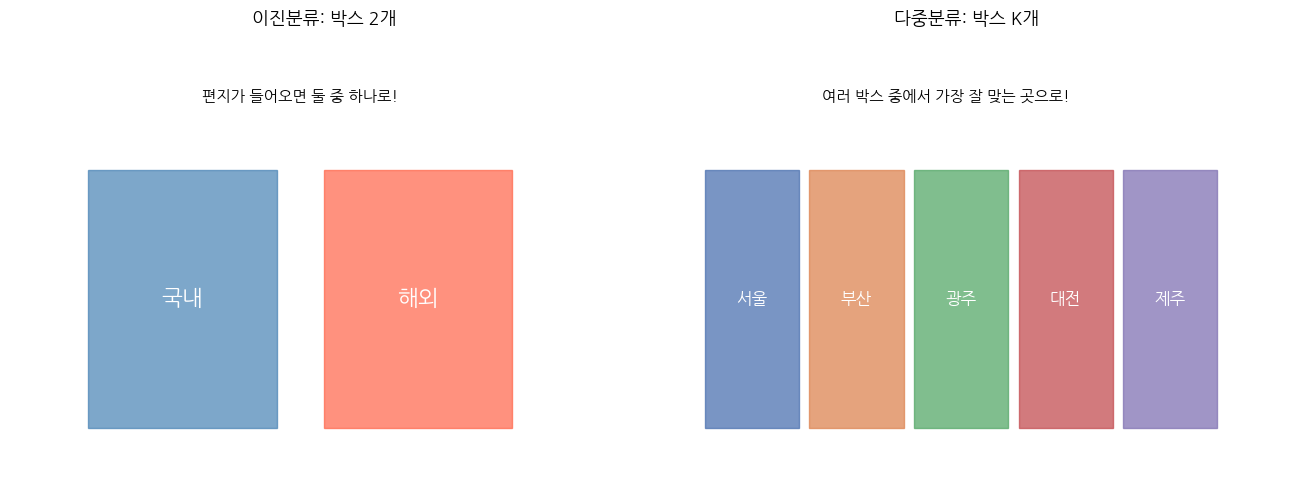

In [4]:
# 🎨 이진분류 vs 다중분류 개념도
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.set_title('이진분류: 박스 2개', fontsize=13, fontweight='bold')
for i, (label, color) in enumerate([('국내', 'steelblue'), ('해외', 'tomato')]):
    rect = plt.Rectangle((i*1.5, 0), 1.2, 1.5, color=color, alpha=0.7)
    ax.add_patch(rect)
    ax.text(i*1.5 + 0.6, 0.75, label, ha='center', va='center',
            fontsize=16, fontweight='bold', color='white')
ax.text(1.35, 1.9, '편지가 들어오면 둘 중 하나로!', ha='center', fontsize=11)
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.3, 2.3); ax.axis('off')

ax = axes[1]
ax.set_title('다중분류: 박스 K개', fontsize=13, fontweight='bold')
labels = ['서울', '부산', '광주', '대전', '제주']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
for i, (label, color) in enumerate(zip(labels, colors)):
    rect = plt.Rectangle((i*1.0, 0), 0.9, 1.5, color=color, alpha=0.75)
    ax.add_patch(rect)
    ax.text(i*1.0 + 0.45, 0.75, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
ax.text(2.3, 1.9, '여러 박스 중에서 가장 잘 맞는 곳으로!', ha='center', fontsize=11)
ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.3, 2.3); ax.axis('off')

plt.tight_layout(); plt.show()

## 🎯 2. Softmax — 점수를 확률로 바꾸는 마법

모델이 처음 내놓는 출력은 **그냥 점수(score)** 입니다. 예를 들어:
> 강아지: **2.0점**, 고양이: **1.0점**, 토끼: **0.1점**

**Softmax**는 이 점수들을 **합이 1이 되는 확률**로 바꿔줍니다.

### 🍰 Softmax의 기능 (한 줄 요약)
> **"큰 점수는 더 크게, 작은 점수는 더 작게, 그리고 전부 더하면 1이 되도록"**

### 📐 수식 (걱정 마세요, 진짜 간단해요)

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

말로 풀면: **"각 점수에 exp를 씌우고, 전체 합으로 나눈다"**

---

## ✏️ 연습 1: Softmax 함수를 직접 만들어 보세요

### 📝 만들어야 할 함수
```python
softmax(z)
# 입력: z (점수 배열, shape=(N, K) 또는 (K,))
# 출력: 확률 배열 (행마다 합이 1)
```

### 💡 힌트 — 3단계로!

1️⃣ **모양 정리**: 1차원 배열도 2차원처럼 다루기
   - `z = np.atleast_2d(z)`  (이미 2차원이면 그대로 둠)

2️⃣ **수치 안정성 트릭** ⚠️ 중요!
   - 점수가 매우 크면 `exp(1000)` 같이 무한대가 나올 수 있음
   - **각 행의 최댓값을 빼주면** 결과는 같으면서 수치는 안정적
   - `z = z - z.max(axis=1, keepdims=True)`

3️⃣ **지수함수 → 정규화**:
   - `e = np.exp(z)`
   - 결과 = `e / e.sum(axis=1, keepdims=True)`

### ⚠️ 주의: `keepdims=True`
- max나 sum을 할 때 `keepdims=True` 가 없으면 차원이 줄어들어 브로드캐스팅이 깨짐
- 항상 `keepdims=True` 를 붙이세요!

In [5]:
# ✏️ 빈칸(...)을 채워서 Softmax를 완성하세요!
def softmax(z):
    # TODO 1: z를 최소 2차원으로 만들기
    z = np.atleast_2d(z)   # 👈 (힌트: np.atleast_2d(z))

    # TODO 2: 수치 안정성을 위해 각 행의 최댓값을 빼기
    z = z - z.max(axis=1, keepdims=True)   # 👈 (힌트: z - z.max(axis=1, keepdims=True))

    # TODO 3: 지수함수 적용
    e = np.exp(z)   # 👈 (힌트: np.exp(z))

    # TODO 4: 각 행의 합으로 나눠서 확률로 만들기
    return e / e.sum(axis=1, keepdims=True) # 👈 (힌트: e / e.sum(axis=1, keepdims=True))

In [6]:
# 🧪 자가 검증
try:
    # 검증 1) 강아지/고양이/토끼 점수
    test_z = np.array([2.0, 1.0, 0.1])
    probs = softmax(test_z)[0]
    expected = np.array([0.659, 0.242, 0.099])

    # 검증 2) 합이 1인지
    sum_ok = abs(probs.sum() - 1.0) < 1e-6

    # 검증 3) 큰 점수에서도 안정적인지 (안정성 트릭 확인)
    big_z = np.array([1000.0, 1001.0, 999.0])
    big_probs = softmax(big_z)[0]
    big_ok = not np.isnan(big_probs).any() and abs(big_probs.sum() - 1.0) < 1e-6

    if np.allclose(probs, expected, atol=0.01) and sum_ok and big_ok:
        print(f"✅ 정답입니다!")
        print(f"   점수 [2.0, 1.0, 0.1] → 확률 {np.round(probs, 3)}")
        print(f"   확률 합 = {probs.sum():.4f} (1.0이어야 함)")
        print(f"   큰 점수에서도 안정적으로 작동: {np.round(big_probs, 3)} ✓")
    else:
        print(f"❌ 다시 시도해보세요.")
        print(f"   기대: [0.659, 0.242, 0.099] / 결과: {np.round(probs, 3)}")
        print(f"   합: {probs.sum():.4f}, 큰 점수 안정성: {big_ok}")
except Exception as e:
    print(f"⚠️  에러 발생: {e}")

✅ 정답입니다!
   점수 [2.0, 1.0, 0.1] → 확률 [0.659 0.242 0.099]
   확률 합 = 1.0000 (1.0이어야 함)
   큰 점수에서도 안정적으로 작동: [0.245 0.665 0.09 ] ✓


<details>
<summary>🔑 정답 보기 (클릭)</summary>

```python
def softmax(z):
    z = np.atleast_2d(z)
    z = z - z.max(axis=1, keepdims=True)   # 수치 안정성 트릭
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)
```

**해설**:
- `z - z.max(...)` 트릭의 핵심: $\frac{e^{z_i}}{\sum e^{z_j}}$ 의 분자/분모 모두에 $e^{-c}$ 를 곱해도 결과가 같음
- 그래서 가장 큰 점수를 빼면 모든 점수가 0 이하가 되고, `exp` 가 폭발하지 않음
- 이 트릭은 **scikit-learn, PyTorch, TensorFlow도 다 사용**하는 표준 기법입니다

</details>

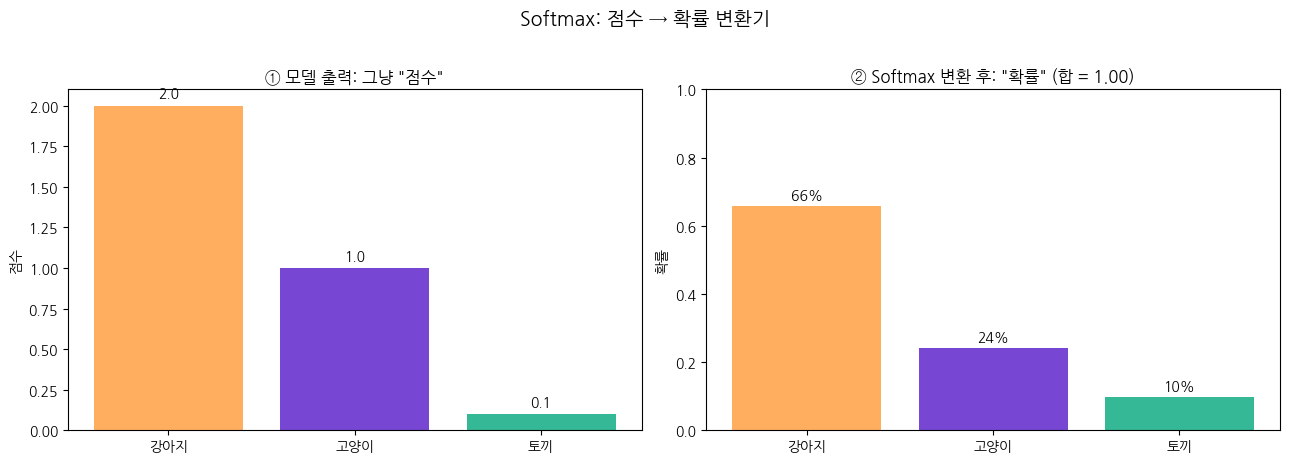

In [7]:
# ✅ 표준 정답 함수 (다음 진행을 위해 실행)
def softmax(z):
    z = np.atleast_2d(z)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

# 동작 확인 + 시각화
scores = np.array([2.0, 1.0, 0.1])
probs = softmax(scores)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
classes = ['강아지', '고양이', '토끼']
colors = ['#FF9F43', '#5F27CD', '#10AC84']

axes[0].bar(classes, scores, color=colors, alpha=0.85)
axes[0].set_title('① 모델 출력: 그냥 "점수"', fontsize=12)
axes[0].set_ylabel('점수'); axes[0].axhline(0, color='gray', linewidth=0.5)
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

axes[1].bar(classes, probs, color=colors, alpha=0.85)
axes[1].set_title(f'② Softmax 변환 후: "확률" (합 = {probs.sum():.2f})', fontsize=12)
axes[1].set_ylabel('확률'); axes[1].set_ylim(0, 1)
for i, v in enumerate(probs):
    axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

plt.suptitle('Softmax: 점수 → 확률 변환기', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 🏷️ 3. 원핫 인코딩 — 정답을 컴퓨터가 알아듣게

| 방법 | 표현 | 문제점 |
|---|---|---|
| ① 그냥 번호 매기기 | 강아지=0, 고양이=1, 토끼=2 | 토끼(2)가 강아지(0)의 2배라는 잘못된 의미 |
| ② **원핫 인코딩** ✅ | 정답 자리만 1, 나머지는 0 | 모든 클래스를 동등하게 |

### 📌 원핫 인코딩 예시 (3종 클래스)

> 정답이 **"고양이"** 일 때 → `[0, 1, 0]`
> 정답이 **"강아지"** 일 때 → `[1, 0, 0]`
> 정답이 **"토끼"** 일 때 → `[0, 0, 1]`

이름 그대로 **단 한 곳만 뜨거운(hot=1)** 인코딩입니다.

---

## ✏️ 연습 2: 원핫 인코딩 함수를 직접 만들어 보세요

### 📝 만들어야 할 함수
```python
one_hot(y, K)
# 입력: y (정수 라벨 배열, shape=(N,)), K (클래스 개수)
# 출력: 원핫 행렬 (shape=(N, K))
```

### 💡 힌트 — 2단계로!

1️⃣ **0으로 채워진 행렬 만들기** (모든 자리가 차가운 상태)
   - `Y = np.zeros((len(y), K))`
   - 행 개수 = 데이터 개수, 열 개수 = 클래스 수

2️⃣ **정답 자리만 1로 만들기** (Fancy Indexing)
   - `Y[np.arange(len(y)), y] = 1`
   - 의미: "0번째 행은 y[0]번째 열, 1번째 행은 y[1]번째 열…에 1을 넣어라"

### 🤔 Fancy Indexing이 헷갈린다면?
- `np.arange(len(y))` = `[0, 1, 2, ...]` (행 인덱스 모두 나열)
- `y` = `[2, 0, 1, ...]` (각 행에서 1이 들어갈 열 위치)
- 이 둘을 함께 쓰면 → "(0,2), (1,0), (2,1), ..." 위치에만 한 번에 1을 넣음

In [12]:
np.arange(3)

array([0, 1, 2])

In [8]:
# ✏️ 빈칸(...)을 채워서 원핫 인코딩 함수를 완성하세요!
def one_hot(y, K):
    # TODO 1: 0으로 채워진 (N, K) 행렬 만들기
    Y = np.zeros((len(y), K))   # 👈 (힌트: np.zeros((len(y), K)))

    # TODO 2: 정답 위치에만 1을 넣기 (Fancy Indexing)
    Y[np.arange(len(y)), y] = 1   # 👈 (힌트: [np.arange(len(y)), y])

    return Y

In [9]:
# 🧪 자가 검증
try:
    # 검증 1) 라벨 [0, 2, 1] → 3x3 원핫
    test_y = np.array([0, 2, 1])
    test_oh = one_hot(test_y, K=3)
    expected = np.array([[1, 0, 0],
                          [0, 0, 1],
                          [0, 1, 0]], dtype=float)

    # 검증 2) 각 행의 합이 모두 1인지
    sum_check = np.allclose(test_oh.sum(axis=1), 1.0)

    if np.array_equal(test_oh, expected) and sum_check:
        print(f"✅ 정답입니다!")
        print(f"   라벨 [0, 2, 1] →")
        print(test_oh)
    else:
        print(f"❌ 다시 시도해보세요.")
        print(f"   기대:\n{expected}\n   결과:\n{test_oh}")
except Exception as e:
    print(f"⚠️  에러 발생: {e}")

✅ 정답입니다!
   라벨 [0, 2, 1] →
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


<details>
<summary>🔑 정답 보기 (클릭)</summary>

```python
def one_hot(y, K):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1
    return Y
```

**해설 (Fancy Indexing의 마법)**:
- `Y[[0, 1, 2], [0, 2, 1]] = 1`은 다음과 똑같습니다:
  - `Y[0, 0] = 1`
  - `Y[1, 2] = 1`
  - `Y[2, 1] = 1`
- 반복문 없이 한 줄로 끝! 이게 넘파이의 매력입니다.

</details>

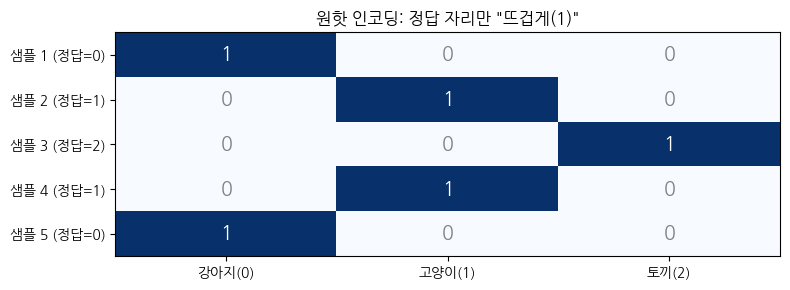

In [13]:
# ✅ 표준 정답 함수
def one_hot(y, K):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1
    return Y

# 시각화
y_example = np.array([0, 1, 2, 1, 0])
Y_onehot = one_hot(y_example, K=3)

fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(Y_onehot, cmap='Blues', aspect='auto')
ax.set_xticks(range(3))
ax.set_xticklabels(['강아지(0)', '고양이(1)', '토끼(2)'])
ax.set_yticks(range(len(y_example)))
ax.set_yticklabels([f'샘플 {i+1} (정답={l})' for i, l in enumerate(y_example)])
for i in range(len(y_example)):
    for j in range(3):
        ax.text(j, i, int(Y_onehot[i, j]), ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if Y_onehot[i, j] > 0.5 else 'gray')
ax.set_title('원핫 인코딩: 정답 자리만 "뜨겁게(1)"', fontsize=12)
plt.tight_layout(); plt.show()

## 🎚️ 4. 크로스 엔트로피 손실 — 분류용 벌점 시스템

### 🎯 핵심 직관

> **"정답에 부여한 확률이 1에 가까울수록 → 손실 0**
> **정답에 부여한 확률이 0에 가까울수록 → 손실이 폭발한다"**

### 📐 수식

$$L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$$

복잡해 보이지만, 원핫 벡터 $y$ 는 **정답 자리만 1**이라서
실제로는 **"정답 클래스 확률에 log를 씌우고 부호를 뒤집어서 평균"** 입니다.

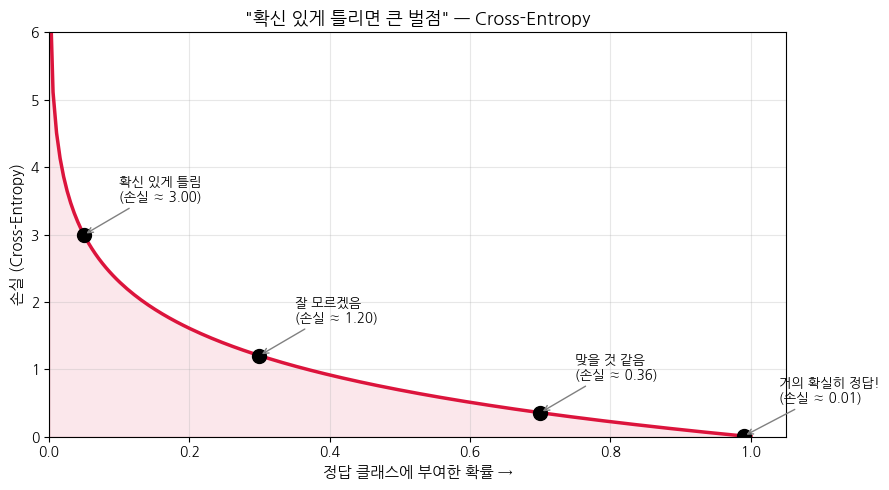

In [14]:
# 🎨 Cross-Entropy 직관 시각화
fig, ax = plt.subplots(figsize=(9, 5))
p = np.linspace(0.001, 1, 200)
loss = -np.log(p)

ax.plot(p, loss, color='crimson', linewidth=2.5)
ax.fill_between(p, 0, loss, color='crimson', alpha=0.1)

points = [(0.99, '거의 확실히 정답!'), (0.7, '맞을 것 같음'),
          (0.3, '잘 모르겠음'), (0.05, '확신 있게 틀림')]
for prob, label in points:
    l = -np.log(prob)
    ax.plot(prob, l, 'o', markersize=10, color='black')
    ax.annotate(f'{label}\n(손실 ≈ {l:.2f})',
                xy=(prob, l), xytext=(prob+0.05, l+0.5),
                fontsize=9.5,
                arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('정답 클래스에 부여한 확률 →', fontsize=11)
ax.set_ylabel('손실 (Cross-Entropy)', fontsize=11)
ax.set_title('"확신 있게 틀리면 큰 벌점" — Cross-Entropy', fontsize=13)
ax.grid(alpha=0.3); ax.set_xlim(0, 1.05); ax.set_ylim(0, 6)
plt.tight_layout(); plt.show()

---

## ✏️ 연습 3: Cross-Entropy 손실 함수를 직접 만들어 보세요

### 📝 만들어야 할 함수
```python
cross_entropy(probs, Y_onehot)
# 입력: probs (모델 예측 확률, shape=(N, K)), Y_onehot (정답 원핫, shape=(N, K))
# 출력: 손실값 1개 숫자
```

### 💡 힌트 — 3단계로!

1️⃣ **log(0) 방지**: probs에 매우 작은 수 더하기 (안전장치)
   - `eps = 1e-12`
   - `np.log(probs + eps)`

2️⃣ **원핫과 곱하면 정답 자리만 살아남음** ✨
   - `Y_onehot * np.log(probs + eps)`
   - 정답이 아닌 자리는 `0 * log(...) = 0` 으로 사라짐!

3️⃣ **샘플별로 합한 뒤, 부호 뒤집어 평균**
   - `-np.mean(np.sum(... , axis=1))`

### 🔬 왜 곱셈 + 합산이 잘 되는가?

```
정답 (원핫): [0, 1, 0]
log 확률:    [-2.3, -0.1, -1.6]
곱하면:      [0,   -0.1,  0  ]   ← 정답 자리만 살아남음!
행 합:       -0.1
부호 뒤집기: 0.1   ← 정답 확률에 -log
```

In [15]:
# ✏️ 빈칸(...)을 채워서 Cross-Entropy를 완성하세요!
def cross_entropy(probs, Y_onehot):
    # TODO 1: log(0) 방지를 위한 작은 수
    eps = 1e-12

    # TODO 2: log를 씌운 확률 구하기 (eps를 더해서 안전하게)
    log_probs = np.log(probs + eps)   # 👈 (힌트: np.log(probs + eps))

    # TODO 3: 원핫과 곱해서 정답 자리만 남기기
    masked = Y_onehot * log_probs      # 👈 (힌트: Y_onehot * log_probs)

    # TODO 4: 행별 합 → 평균 → 부호 뒤집기
    return -np.mean(np.sum(masked, axis=1))        # 👈 (힌트: -np.mean(np.sum(masked, axis=1)))

In [16]:
# 🧪 자가 검증
try:
    # 검증 1) 잘 맞힌 경우 → 손실 작음
    Y_true = np.array([[1, 0, 0]])
    probs_good = np.array([[0.9, 0.05, 0.05]])
    loss_good = cross_entropy(probs_good, Y_true)

    # 검증 2) 못 맞힌 경우 → 손실 큼
    probs_bad = np.array([[0.1, 0.6, 0.3]])
    loss_bad = cross_entropy(probs_bad, Y_true)

    # 정답: -log(0.9) ≈ 0.1054, -log(0.1) ≈ 2.3026
    expected_good = -np.log(0.9)
    expected_bad  = -np.log(0.1)

    if (abs(loss_good - expected_good) < 1e-3 and
        abs(loss_bad - expected_bad) < 1e-3 and
        loss_bad > loss_good):
        print(f"✅ 정답입니다!")
        print(f"   잘 맞힌 경우 (90%): 손실 = {loss_good:.4f}  (작음 = 좋음)")
        print(f"   틀린 경우  (10%): 손실 = {loss_bad:.4f}  (큼 = 벌점!)")
        print(f"   → 확신 있게 틀릴수록 손실이 커지는 게 잘 작동합니다 🎉")
    else:
        print(f"❌ 다시 시도해보세요.")
        print(f"   기대: 잘맞힘 ≈ {expected_good:.3f}, 틀림 ≈ {expected_bad:.3f}")
        print(f"   결과: {loss_good:.4f}, {loss_bad:.4f}")
except Exception as e:
    print(f"⚠️  에러 발생: {e}")

✅ 정답입니다!
   잘 맞힌 경우 (90%): 손실 = 0.1054  (작음 = 좋음)
   틀린 경우  (10%): 손실 = 2.3026  (큼 = 벌점!)
   → 확신 있게 틀릴수록 손실이 커지는 게 잘 작동합니다 🎉


<details>
<summary>🔑 정답 보기 (클릭)</summary>

```python
def cross_entropy(probs, Y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(Y_onehot * np.log(probs + eps), axis=1))
```

**해설**:
- `eps = 1e-12`: 모델이 어떤 클래스에 0% 확률을 줬을 때 `log(0) = -∞` 문제 방지
- `Y_onehot * np.log(probs)`: 원핫이 0인 자리는 통째로 0이 되어 **정답 클래스만 영향을 줌**
- `axis=1`: 각 샘플(행)별로 합산
- 부호 뒤집기 `-`: 확률은 0~1, log는 음수 → 부호 뒤집어서 양수 손실로

</details>

In [17]:
# ✅ 표준 정답 함수
def cross_entropy(probs, Y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(Y_onehot * np.log(probs + eps), axis=1))

print("✅ 세 함수(softmax, one_hot, cross_entropy) 준비 완료!")

✅ 세 함수(softmax, one_hot, cross_entropy) 준비 완료!


## 💻 5. 실습 ①: 2D 가상 데이터로 분류기 만들기

이론은 이만하면 충분! 만든 함수들을 가지고 진짜 분류기를 학습시켜 봅시다.

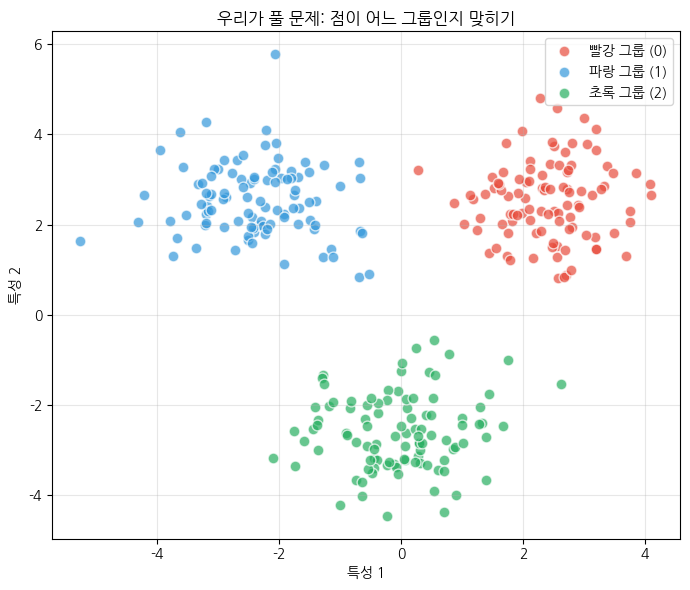

총 데이터: 300개


In [18]:
# 2D 가상 데이터: 3개 클래스
np.random.seed(42)
n_per_class = 100
centers = np.array([[2.5, 2.5], [-2.5, 2.5], [0, -2.5]])
class_names = ['빨강 그룹 (0)', '파랑 그룹 (1)', '초록 그룹 (2)']
class_colors = ['#E74C3C', '#3498DB', '#27AE60']

X_list, y_list = [], []
for i, c in enumerate(centers):
    pts = np.random.randn(n_per_class, 2) * 0.85 + c
    X_list.append(pts); y_list.append(np.full(n_per_class, i))
X = np.vstack(X_list); y = np.concatenate(y_list)

idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

plt.figure(figsize=(7, 6))
for i in range(3):
    mask = (y == i)
    plt.scatter(X[mask, 0], X[mask, 1], c=class_colors[i],
                label=class_names[i], alpha=0.7, edgecolor='white', s=60)
plt.xlabel('특성 1'); plt.ylabel('특성 2')
plt.title('우리가 풀 문제: 점이 어느 그룹인지 맞히기')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"총 데이터: {len(X)}개")

### ⚙️ 분류기 학습 함수

지난 시간에 만든 **미니배치 GD를 그대로** 사용합니다. 출력만 Softmax + Cross-Entropy로 바뀌었어요!

In [19]:
# 기울기 함수 (Softmax + Cross-Entropy 조합의 깔끔한 결과)
def compute_gradient_clf(X, Y_onehot, W, b):
    z = X @ W + b
    probs = softmax(z)
    dz = (probs - Y_onehot) / len(X)   # 깔끔한 식의 비밀!
    dW = X.T @ dz
    db = dz.sum(axis=0)
    return dW, db

# 미니배치 경사하강법으로 분류기 학습 (지난 시간과 같은 패턴!)
def train_classifier(X, y, K, lr=0.5, epochs=100, batch_size=32):
    n, d = X.shape
    Y = one_hot(y, K)
    W = np.zeros((d, K)); b = np.zeros(K)
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            bi = idx[start:start + batch_size]
            Xb, Yb = X[bi], Y[bi]
            dW, db_ = compute_gradient_clf(Xb, Yb, W, b)
            W -= lr * dW
            b -= lr * db_

        probs_full = softmax(X @ W + b)
        history['loss'].append(cross_entropy(probs_full, Y))
        history['acc'].append((probs_full.argmax(1) == y).mean())
    return W, b, history

print("✅ 분류기 학습 함수 준비!")
print("   👉 지난 시간 미니배치 GD와 거의 같음. 손실만 Cross-Entropy로!")

✅ 분류기 학습 함수 준비!
   👉 지난 시간 미니배치 GD와 거의 같음. 손실만 Cross-Entropy로!


최종 정확도: 100.0%
최종 손실:   0.0030


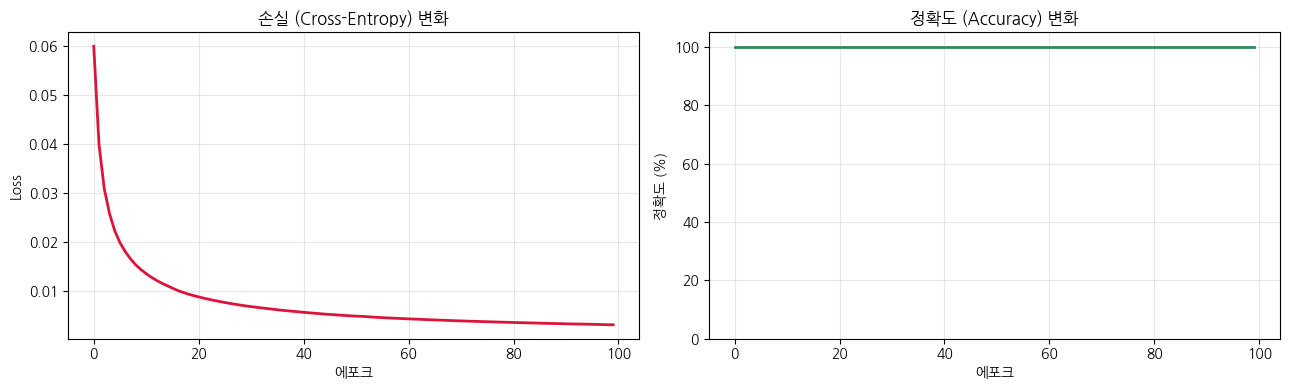

In [20]:
# 🚀 학습 실행!
np.random.seed(0)
W, b, history = train_classifier(X, y, K=3, lr=0.5, epochs=100, batch_size=32)

print(f"최종 정확도: {history['acc'][-1]:.1%}")
print(f"최종 손실:   {history['loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['loss'], color='crimson', linewidth=2)
axes[0].set_title('손실 (Cross-Entropy) 변화')
axes[0].set_xlabel('에포크'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

axes[1].plot([a * 100 for a in history['acc']], color='seagreen', linewidth=2)
axes[1].set_title('정확도 (Accuracy) 변화')
axes[1].set_xlabel('에포크'); axes[1].set_ylabel('정확도 (%)')
axes[1].set_ylim(0, 105); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

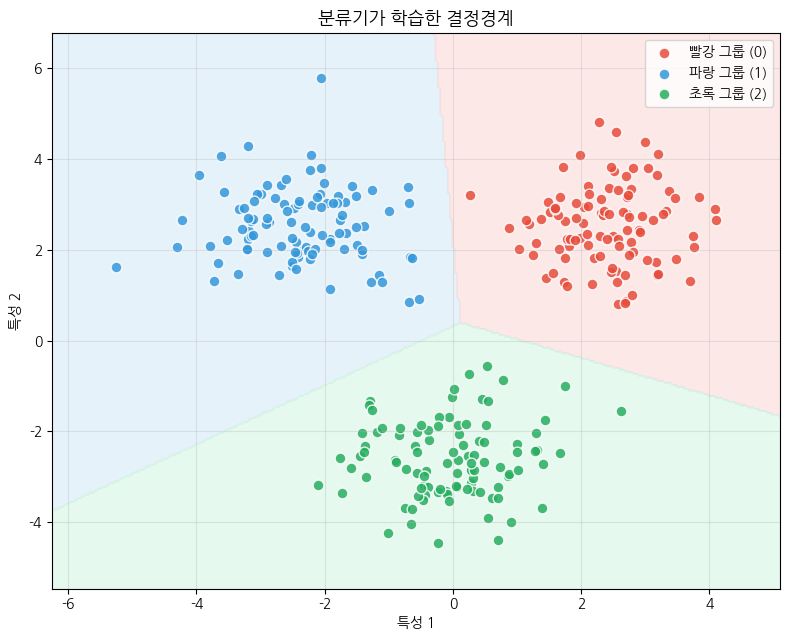

👀 분류기가 평면을 3개 영역으로 나눴습니다!
        세 영역의 경계선을 '결정경계'라고 부릅니다.


In [21]:
# 🗺️ 결정경계 시각화
def plot_decision_boundary(X, y, W, b, title='결정경계'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = softmax(grid @ W + b).argmax(1).reshape(xx.shape)

    from matplotlib.colors import ListedColormap
    cmap_bg = ListedColormap(['#FADBD8', '#D6EAF8', '#D5F5E3'])

    plt.figure(figsize=(8, 6.5))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap=cmap_bg)
    for i in range(3):
        mask = (y == i)
        plt.scatter(X[mask, 0], X[mask, 1], c=class_colors[i],
                    label=class_names[i], alpha=0.85, edgecolor='white', s=60)
    plt.xlabel('특성 1'); plt.ylabel('특성 2'); plt.title(title, fontsize=13)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plot_decision_boundary(X, y, W, b, title='분류기가 학습한 결정경계')

print("👀 분류기가 평면을 3개 영역으로 나눴습니다!")
print("        세 영역의 경계선을 '결정경계'라고 부릅니다.")

## 📋 6. 혼동행렬 (Confusion Matrix)

정확도 90%라고 해도 **"어느 클래스에서 틀렸는지"** 는 알 수 없죠.
**혼동행렬**은 모델이 어떤 클래스를 어떤 클래스로 잘못 봤는지 보여줍니다.

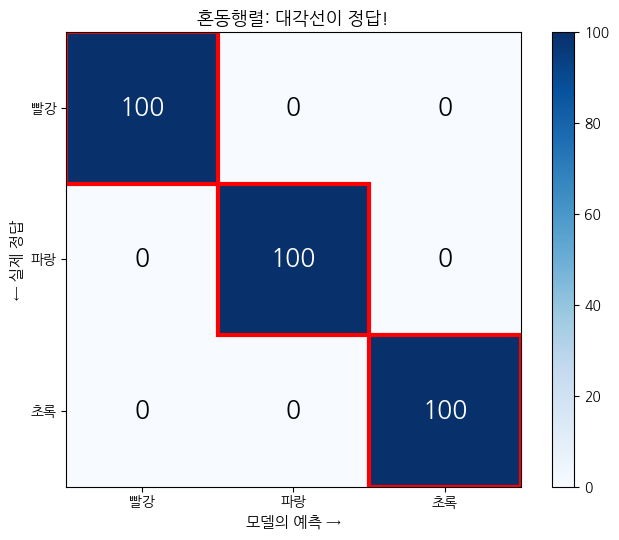


전체 정확도: 100.0%


In [22]:
# 혼동행렬 함수
def confusion_matrix(y_true, y_pred, K):
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

y_pred = softmax(X @ W + b).argmax(axis=1)
cm = confusion_matrix(y, y_pred, K=3)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm, cmap='Blues')
short_names = ['빨강', '파랑', '초록']
ax.set_xticks(range(3)); ax.set_xticklabels(short_names)
ax.set_yticks(range(3)); ax.set_yticklabels(short_names)
ax.set_xlabel('모델의 예측 →', fontsize=11, fontweight='bold')
ax.set_ylabel('← 실제 정답', fontsize=11, fontweight='bold')
ax.set_title('혼동행렬: 대각선이 정답!', fontsize=13)

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
        if i == j:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                        fill=False, edgecolor='red', linewidth=3))
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

print(f"\n전체 정확도: {(y_pred == y).mean():.1%}")

## 🌸 7. 실습 ②: 진짜 데이터로 — 붓꽃(Iris) 3종 분류

머신러닝의 가장 유명한 입문 데이터인 **Iris(붓꽃) 데이터셋**을 사용합니다.
- 샘플 150개, 특성 4개, 클래스 3종 (Setosa, Versicolor, Virginica)

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X_iris = iris.data; y_iris = iris.target
feature_names = iris.feature_names; target_names = iris.target_names

print(f"데이터 모양: {X_iris.shape}")
print(f"특성 이름:   {feature_names}")
print(f"클래스:      {list(target_names)}")

# 표준화
mean, std = X_iris.mean(axis=0), X_iris.std(axis=0)
X_iris_scaled = (X_iris - mean) / std

# 학습/테스트 분할
X_tr, X_te, y_tr, y_te = train_test_split(X_iris_scaled, y_iris,
                                           test_size=0.3, random_state=42,
                                           stratify=y_iris)
print(f"\n학습: {len(X_tr)}개,  테스트: {len(X_te)}개")

데이터 모양: (150, 4)
특성 이름:   ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스:      [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

학습: 105개,  테스트: 45개


🎯 학습 데이터 정확도:  97.1%
🎯 테스트 데이터 정확도: 91.1%


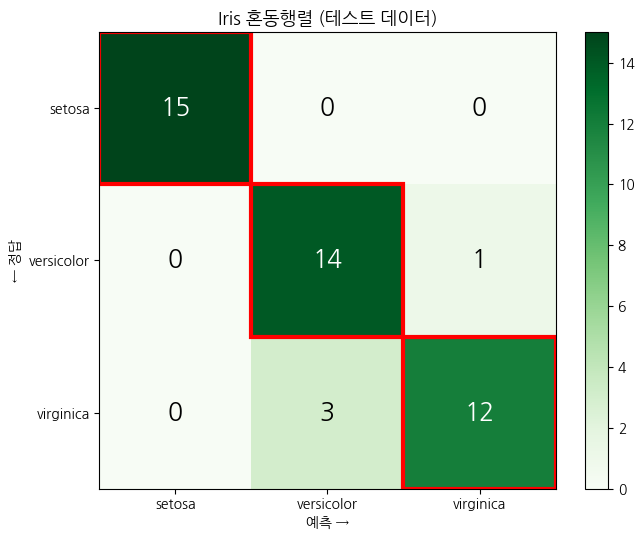

In [24]:
# 🚀 학습!
np.random.seed(0)
W_iris, b_iris, hist_iris = train_classifier(X_tr, y_tr, K=3,
                                              lr=0.3, epochs=200, batch_size=16)

train_acc = (softmax(X_tr @ W_iris + b_iris).argmax(1) == y_tr).mean()
test_acc  = (softmax(X_te @ W_iris + b_iris).argmax(1) == y_te).mean()

print(f"🎯 학습 데이터 정확도:  {train_acc:.1%}")
print(f"🎯 테스트 데이터 정확도: {test_acc:.1%}")

# 혼동행렬
y_pred_iris = softmax(X_te @ W_iris + b_iris).argmax(axis=1)
cm_iris = confusion_matrix(y_te, y_pred_iris, K=3)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm_iris, cmap='Greens')
ax.set_xticks(range(3)); ax.set_xticklabels(target_names)
ax.set_yticks(range(3)); ax.set_yticklabels(target_names)
ax.set_xlabel('예측 →', fontweight='bold'); ax.set_ylabel('← 정답', fontweight='bold')
ax.set_title('Iris 혼동행렬 (테스트 데이터)', fontsize=13)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm_iris[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_iris[i, j] > cm_iris.max()/2 else 'black')
        if i == j:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                        fill=False, edgecolor='red', linewidth=3))
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

In [25]:
# 🔍 새로운 꽃 한 송이 분류해보기
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # 꽃받침/꽃잎 크기 (cm)
new_flower_scaled = (new_flower - mean) / std

probs_new = softmax(new_flower_scaled @ W_iris + b_iris)[0]
pred_idx = probs_new.argmax()

print(f"입력한 꽃: 꽃받침({new_flower[0,0]}, {new_flower[0,1]}cm), 꽃잎({new_flower[0,2]}, {new_flower[0,3]}cm)")
print(f"\n각 종일 확률:")
for i, name in enumerate(target_names):
    bar = '█' * int(probs_new[i] * 30)
    print(f"  {name:12s}: {probs_new[i]:.1%}  {bar}")
print(f"\n🌸 예측 결과: '{target_names[pred_idx]}' (확률 {probs_new[pred_idx]:.1%})")

입력한 꽃: 꽃받침(5.1, 3.5cm), 꽃잎(1.4, 0.2cm)

각 종일 확률:
  setosa      : 99.8%  █████████████████████████████
  versicolor  : 0.2%  
  virginica   : 0.0%  

🌸 예측 결과: 'setosa' (확률 99.8%)


## 🧪 직접 해보기 (자유 도전)

### 도전 1️⃣: 새 꽃 직접 분류
바로 위 셀의 `new_flower` 값을 바꿔보세요!
- `[6.5, 3.0, 5.5, 2.0]` → 어떤 종으로?
- `[5.8, 2.7, 4.1, 1.0]` → 헷갈리는 케이스?

### 도전 2️⃣: 학습률 / 배치 크기 바꿔보기
`train_classifier(X, y, K=3, lr=??, epochs=??, batch_size=??)` 의 숫자를 바꿔보세요.

---

## 🎓 8. 한 장으로 정리

### ✨ 오늘 직접 만든 것 3가지

1. ✏️ **Softmax** — 점수를 확률로 변환 (수치 안정성 트릭 포함!)
2. ✏️ **원핫 인코딩** — 정답 자리만 1로 표현
3. ✏️ **Cross-Entropy** — 정답 확률에 -log를 씌운 평균 손실

### 🗝️ 회귀(지난시간) vs 분류(이번시간)

| | 회귀 | 분류 |
|---|---|---|
| **모델 출력** | 그냥 숫자 1개 | 클래스별 확률 (합=1) |
| **마지막 함수** | 없음 | **Softmax** ✨ |
| **정답 표현** | 숫자 그대로 | **원핫 벡터** ✨ |
| **손실 함수** | MSE | **Cross-Entropy** ✨ |
| **학습 방법** | 미니배치 GD | **미니배치 GD** ← 똑같음! |

### 💪 다음에 배울 만한 것

- **신경망**: 오늘 모델은 직선 1개씩으로 나누는 모델 → 곡선으로 나누고 싶다면 신경망!
- **이미지 분류**: 손글씨 0~9 (MNIST), 사진 1000종 (ImageNet)
- **불균형 데이터 다루기**: 한 클래스가 압도적으로 많을 때

---

> 🎉 **수고하셨습니다!**
> 빈칸 3개를 모두 직접 채워서 작동시켰다면, 이제 sklearn이나 PyTorch가 안에서
> 무슨 일을 하는지 아는 사람이 됐습니다.